# Plot Vdevice curves from `vdevice_curves_full.json`

2×2 layout: **rows** α = nq, nq/2; **columns** prep ε_p = 0.05, 0.01.  
No shading. Shared x and y axes, no spacing. Y-axis [0.5, 1].  
Column 0: n_q ∈ [0, 50]; column 1: n_q ∈ [0, 100].

In [75]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'figures_notebooks' else Path.cwd()

plt.style.use(str(REPO_ROOT / "single_column.mplstyle"))

DATA_PATH = str(REPO_ROOT / "vdevice_curves_full.json")

# Rows = alpha; columns = prep. Column 0: nq 0–50, column 1: nq 0–100
PREP_VALS = ["0.05", "0.01"]   # column 0, column 1
NQ_MAX_PER_COL = [50, 100]     # max nq for each column
alpha_patterns = ["nq", "nq/2"]  # row 0, row 1
READOUT = "0%"   # no shading, single readout


Bad key axes.grid.alpha in file single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.7/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [76]:
with open(DATA_PATH) as f:
    data = json.load(f)

nq = np.array(data["nq_values"])
devices = data["devices"]
channels = data["channels"]
curves = data["curves"]

device_colors = {"I": "C0", "S": "C1", "T": "C2"}
channel_linestyle = {"dephasing": "-", "depolarizing": "--", "relaxation": "-."}

# Proxy artists for separate legends
from matplotlib.lines import Line2D
legend_devices = [Line2D([0], [0], color=device_colors[d], lw=2.5, label=d) for d in devices]
legend_channels = [Line2D([0], [0], color="k", ls=channel_linestyle[c], lw=2, label=c) for c in channels]

/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_19092/2854079953.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_19092/2854079953.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_19092/2854079953.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_19092/2854079953.py:26: UserWarning: set_ticklabels() should only be

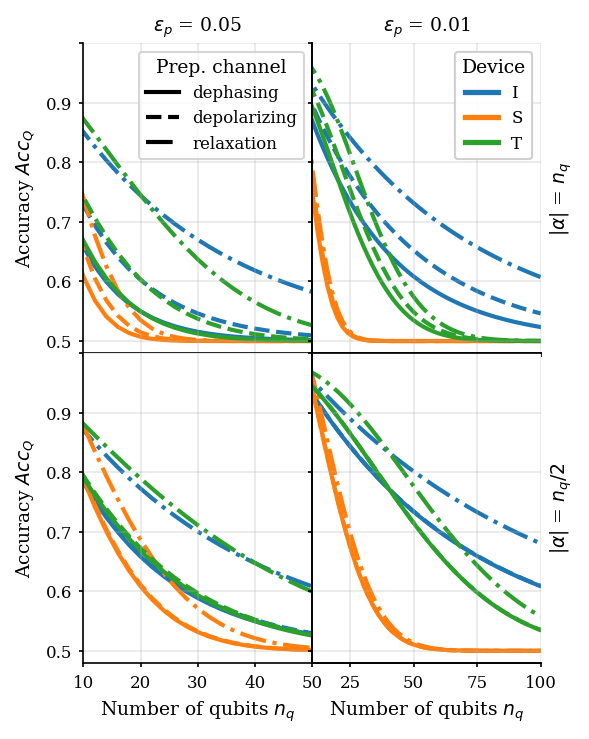

In [81]:
fig, axes = plt.subplots(
    2, 2, figsize=(4, 5), sharex="col", sharey=True,
    gridspec_kw={"hspace": 0, "wspace": 0}
)
# rows = alpha (nq, nq/2), cols = prep (0.05, 0.01)

for i_row, alpha_key in enumerate(alpha_patterns):
    for i_col, prep in enumerate(PREP_VALS):
        ax = axes[i_row, i_col]
        nq_max = NQ_MAX_PER_COL[i_col]
        mask = nq <= nq_max
        nq_plot = nq[mask]

        for device in devices:
            color = device_colors[device]
            for channel in channels:
                ls = channel_linestyle[channel]
                y = np.array(curves[device][channel][alpha_key][READOUT][prep])[mask]
                ax.plot(nq_plot, y, color=color, ls=ls, label=f"{device} {channel}", zorder=1, lw = 2)

        ax.set_ylim(0.48, 1)
        ax.set_xlim(10, nq_max)
        ax.grid(True, alpha=0.3)
        # Hide y-tick label at 1.0 (no label on top of axis)
        yticks = ax.get_yticks()
        ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
        if i_col == 0:
            ax.set_ylabel("Accuracy $Acc_Q$")
        if i_row == 1:
            ax.set_xlabel("Number of qubits $n_q$")
        if i_row == 0:
            ax.set_title(f"$\\epsilon_p$ = {prep}")
        if i_col == 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"$|\\alpha|$ = $n_q/2$" if alpha_key == "nq/2" else f"$|\\alpha|$ = $n_q$")
            ax2.set_yticks([])
        if i_row == 0 and i_col == 1:
            leg_dev = ax.legend(handles=legend_devices, title="Device", loc="upper right", fontsize=8)
            ax.add_artist(leg_dev)

        if i_row == 0 and i_col == 0:
            ax.legend(handles=legend_channels, title="Prep. channel", loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(str(REPO_ROOT / "figures_manuscript" / "fig2_quantum_acc.pdf"), bbox_inches='tight')